In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Set display options
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

# Project paths
BASE_DIR = Path.cwd().parent if Path.cwd().name == "python" else Path.cwd()
DB_PATH = BASE_DIR / "database" / "ravenstack.db"

print("Database path:", DB_PATH)
print("Database exists:", DB_PATH.exists())

Database path: d:\SaaS Customer Churn Revenue Risk Analysis\database\ravenstack.db
Database exists: True


In [2]:
conn = sqlite3.connect(DB_PATH)

accounts = pd.read_sql_query("SELECT * FROM accounts", conn)
subscriptions = pd.read_sql_query("SELECT * FROM subscriptions", conn)
feature_usage = pd.read_sql_query("SELECT * FROM feature_usage", conn)
support_tickets = pd.read_sql_query("SELECT * FROM support_tickets", conn)
churn_events = pd.read_sql_query("SELECT * FROM churn_events", conn)

conn.close()

print("Accounts:", accounts.shape)
print("Subscriptions:", subscriptions.shape)
print("Feature usage:", feature_usage.shape)
print("Support tickets:", support_tickets.shape)
print("Churn events:", churn_events.shape)

Accounts: (500, 10)
Subscriptions: (5000, 14)
Feature usage: (25000, 8)
Support tickets: (2000, 9)
Churn events: (600, 9)


In [3]:
# Account-level revenue summary from subscriptions table

revenue_by_account = (
    subscriptions
    .groupby("account_id", as_index=False)
    .agg(
        total_mrr=("mrr_amount", "sum"),
        total_arr=("arr_amount", "sum"),
        avg_mrr=("mrr_amount", "mean"),
        subscription_count=("subscription_id", "count"),
        churned_subscription_records=("churn_flag", "sum")
    )
)

revenue_by_account.head()

,account_id,total_mrr,total_arr,avg_mrr,subscription_count,churned_subscription_records
0,A-00bed1,33506,402072,"3,350.60",10,0
1,A-00cac8,14121,169452,"1,569.00",9,0
2,A-0158bb,4070,48840,678.33,6,0
3,A-016043,16516,198192,"1,501.45",11,1
4,A-019782,8353,100236,928.11,9,1


In [4]:
# Merge account profile with revenue summary

account_analysis = accounts.merge(
    revenue_by_account,
    on="account_id",
    how="left"
)

account_analysis.head()

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag,total_mrr,total_arr,avg_mrr,subscription_count,churned_subscription_records
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,0,0,12603,151236,"1,260.30",10,0
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,0,1,10004,120048,"1,250.50",8,0
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,0,0,18286,219432,"1,219.07",15,3
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,1,0,9275,111300,"1,325.00",7,0
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,0,1,48761,585132,"5,417.89",9,2


In [5]:
print("Final account analysis shape:", account_analysis.shape)
account_analysis.head()

Final account analysis shape: (500, 15)


,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag,total_mrr,total_arr,avg_mrr,subscription_count,churned_subscription_records
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,0,0,12603,151236,"1,260.30",10,0
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,0,1,10004,120048,"1,250.50",8,0
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,0,0,18286,219432,"1,219.07",15,3
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,1,0,9275,111300,"1,325.00",7,0
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,0,1,48761,585132,"5,417.89",9,2


In [ ]:
# Create folder for Python chart outputs

PYTHON_CHARTS_DIR = BASE_DIR / "reports" / "python_charts"
PYTHON_CHARTS_DIR.mkdir(parents=True, exist_ok=True)

print("Python charts folder:", PYTHON_CHARTS_DIR)

Python charts folder: d:\SaaS Customer Churn Revenue Risk Analysis\reports\python_charts


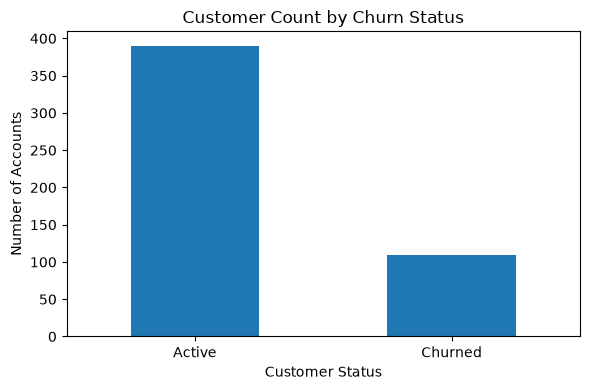

In [11]:
churn_counts = account_analysis["churn_flag"].value_counts().rename(index={0: "Active", 1: "Churned"})

ax = churn_counts.plot(kind="bar", figsize=(6, 4))
plt.title("Customer Count by Churn Status")
plt.xlabel("Customer Status")
plt.ylabel("Number of Accounts")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(PYTHON_CHARTS_DIR / "01_customer_count_by_churn_status.png", dpi=300, bbox_inches="tight")
plt.show()

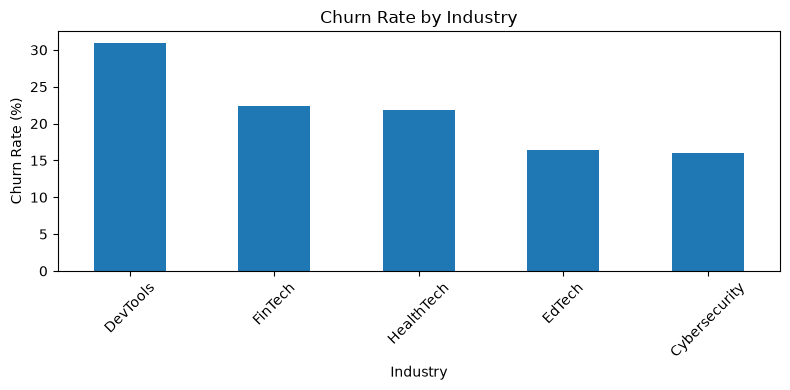

In [12]:
ax = industry_churn.plot(
    x="industry",
    y="churn_rate_percentage",
    kind="bar",
    figsize=(8, 4),
    legend=False
)

plt.title("Churn Rate by Industry")
plt.xlabel("Industry")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(PYTHON_CHARTS_DIR / "02_churn_rate_by_industry.png", dpi=300, bbox_inches="tight")
plt.show()

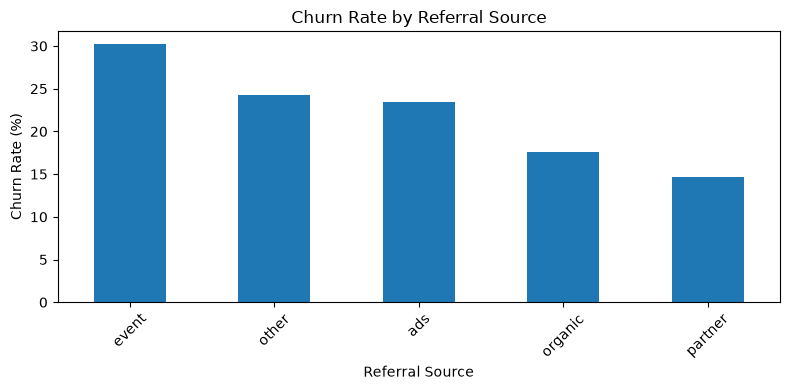

In [13]:
ax = referral_churn.plot(
    x="referral_source",
    y="churn_rate_percentage",
    kind="bar",
    figsize=(8, 4),
    legend=False
)

plt.title("Churn Rate by Referral Source")
plt.xlabel("Referral Source")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(PYTHON_CHARTS_DIR / "03_churn_rate_by_referral_source.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
# Feature usage summary by subscription

usage_by_subscription = (
    feature_usage
    .groupby("subscription_id", as_index=False)
    .agg(
        total_usage_count=("usage_count", "sum"),
        avg_usage_duration_secs=("usage_duration_secs", "mean"),
        total_errors=("error_count", "sum"),
        beta_feature_events=("is_beta_feature", "sum"),
        unique_features_used=("feature_name", "nunique")
    )
)

usage_by_subscription.head()

,subscription_id,total_usage_count,avg_usage_duration_secs,total_errors,beta_feature_events,unique_features_used
0,S-001561,48,"4,320.80",3,0,5
1,S-0027d3,44,"5,212.00",0,0,3
2,S-003647,71,"1,627.25",3,2,8
3,S-003fc0,43,"2,983.25",1,0,4
4,S-004d19,18,"2,808.00",0,0,2


In [15]:
# Merge feature usage with subscription and account information

usage_analysis = (
    usage_by_subscription
    .merge(
        subscriptions[["subscription_id", "account_id", "plan_tier", "churn_flag", "mrr_amount", "arr_amount"]],
        on="subscription_id",
        how="left"
    )
    .merge(
        accounts[["account_id", "industry", "referral_source"]],
        on="account_id",
        how="left"
    )
)

print("Usage analysis shape:", usage_analysis.shape)
usage_analysis.head()

Usage analysis shape: (4967, 13)


,subscription_id,total_usage_count,avg_usage_duration_secs,total_errors,beta_feature_events,unique_features_used,account_id,plan_tier,churn_flag,mrr_amount,arr_amount,industry,referral_source
0,S-001561,48,"4,320.80",3,0,5,A-1b7577,Enterprise,0,1194,14328,Cybersecurity,other
1,S-0027d3,44,"5,212.00",0,0,3,A-e693b6,Basic,0,1045,12540,FinTech,event
2,S-003647,71,"1,627.25",3,2,8,A-e36807,Enterprise,0,1791,21492,EdTech,other
3,S-003fc0,43,"2,983.25",1,0,4,A-65c341,Basic,0,0,0,FinTech,ads
4,S-004d19,18,"2,808.00",0,0,2,A-bece89,Enterprise,0,5174,62088,Cybersecurity,event


In [16]:
# Compare product usage by churn status

usage_by_churn = (
    usage_analysis
    .groupby("churn_flag")
    .agg(
        total_subscriptions=("subscription_id", "count"),
        avg_usage_count=("total_usage_count", "mean"),
        avg_usage_duration_secs=("avg_usage_duration_secs", "mean"),
        avg_errors=("total_errors", "mean"),
        avg_unique_features_used=("unique_features_used", "mean"),
        avg_beta_feature_events=("beta_feature_events", "mean")
    )
    .reset_index()
)

usage_by_churn["churn_status"] = usage_by_churn["churn_flag"].map({0: "Active", 1: "Churned"})

display(usage_by_churn)

,churn_flag,total_subscriptions,avg_usage_count,avg_usage_duration_secs,avg_errors,avg_unique_features_used,avg_beta_feature_events,churn_status
0,0,4484,50.56,"3,040.11",2.85,4.74,0.51,Active
1,1,483,49.29,"3,032.42",2.78,4.63,0.50,Churned


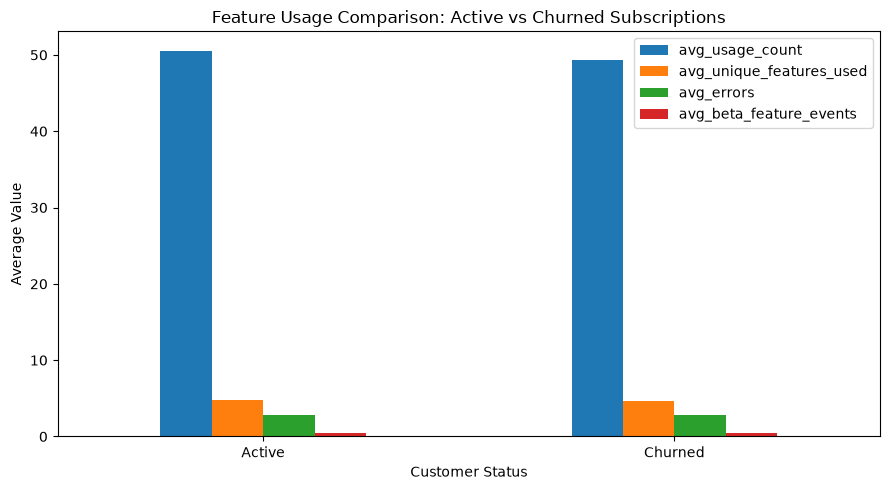

In [17]:
# Save feature usage comparison chart

usage_metrics = usage_by_churn.set_index("churn_status")[
    ["avg_usage_count", "avg_unique_features_used", "avg_errors", "avg_beta_feature_events"]
]

ax = usage_metrics.plot(kind="bar", figsize=(9, 5))

plt.title("Feature Usage Comparison: Active vs Churned Subscriptions")
plt.xlabel("Customer Status")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(PYTHON_CHARTS_DIR / "04_feature_usage_active_vs_churned.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
# Support ticket summary by account

support_by_account = (
    support_tickets
    .groupby("account_id", as_index=False)
    .agg(
        total_tickets=("ticket_id", "count"),
        avg_resolution_time_hours=("resolution_time_hours", "mean"),
        avg_first_response_time_minutes=("first_response_time_minutes", "mean"),
        avg_satisfaction_score=("satisfaction_score", "mean"),
        total_escalations=("escalation_flag", "sum")
    )
)

support_by_account.head()

,account_id,total_tickets,avg_resolution_time_hours,avg_first_response_time_minutes,avg_satisfaction_score,total_escalations
0,A-00bed1,4,31.75,106.25,4.00,0
1,A-00cac8,2,33.00,120.50,NaN,0
2,A-0158bb,1,32.00,50.00,3.00,0
3,A-016043,3,30.33,78.00,4.00,0
4,A-019782,2,10.00,107.00,3.00,0


In [19]:
# Merge support data with account-level analysis

support_analysis = account_analysis.merge(
    support_by_account,
    on="account_id",
    how="left"
)

# Replace missing support values with 0 for accounts with no tickets
support_cols = [
    "total_tickets",
    "avg_resolution_time_hours",
    "avg_first_response_time_minutes",
    "avg_satisfaction_score",
    "total_escalations"
]

support_analysis[support_cols] = support_analysis[support_cols].fillna(0)

print("Support analysis shape:", support_analysis.shape)
support_analysis.head()

Support analysis shape: (500, 20)


,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag,total_mrr,total_arr,avg_mrr,subscription_count,churned_subscription_records,total_tickets,avg_resolution_time_hours,avg_first_response_time_minutes,avg_satisfaction_score,total_escalations
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,0,0,12603,151236,"1,260.30",10,0,2.00,23.00,91.00,3.00,0.00
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,0,1,10004,120048,"1,250.50",8,0,3.00,38.00,73.33,4.00,0.00
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,0,0,18286,219432,"1,219.07",15,3,3.00,43.67,63.67,4.67,0.00
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,1,0,9275,111300,"1,325.00",7,0,2.00,29.00,174.00,0.00,0.00
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,0,1,48761,585132,"5,417.89",9,2,7.00,42.29,107.86,3.80,1.00


In [20]:
# Compare support experience by churn status

support_by_churn = (
    support_analysis
    .groupby("churn_flag")
    .agg(
        total_accounts=("account_id", "count"),
        avg_tickets=("total_tickets", "mean"),
        avg_resolution_time_hours=("avg_resolution_time_hours", "mean"),
        avg_first_response_time_minutes=("avg_first_response_time_minutes", "mean"),
        avg_satisfaction_score=("avg_satisfaction_score", "mean"),
        avg_escalations=("total_escalations", "mean")
    )
    .reset_index()
)

support_by_churn["churn_status"] = support_by_churn["churn_flag"].map({0: "Active", 1: "Churned"})

display(support_by_churn)

,churn_flag,total_accounts,avg_tickets,avg_resolution_time_hours,avg_first_response_time_minutes,avg_satisfaction_score,avg_escalations,churn_status
0,0,390,4.02,35.89,88.20,3.69,0.18,Active
1,1,110,3.93,34.84,83.38,3.71,0.22,Churned


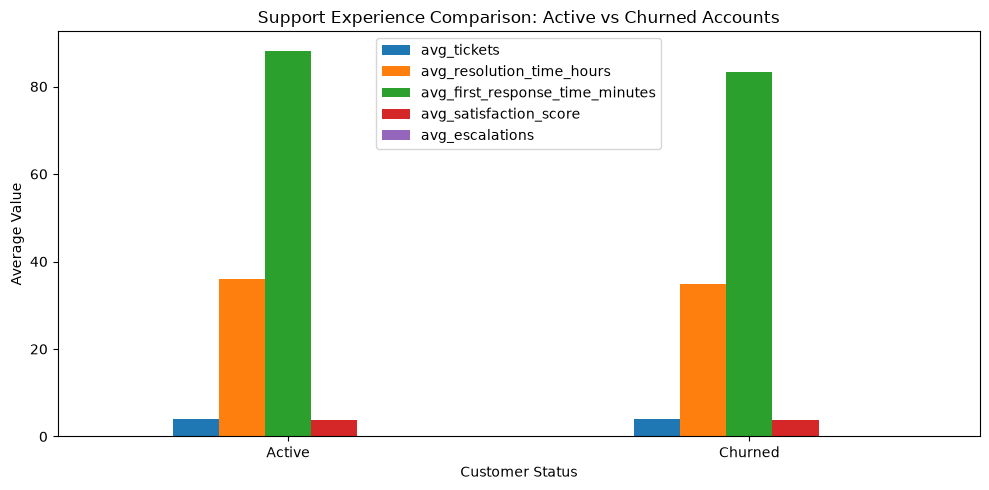

In [21]:
# Save support experience comparison chart

support_metrics = support_by_churn.set_index("churn_status")[
    [
        "avg_tickets",
        "avg_resolution_time_hours",
        "avg_first_response_time_minutes",
        "avg_satisfaction_score",
        "avg_escalations"
    ]
]

ax = support_metrics.plot(kind="bar", figsize=(10, 5))

plt.title("Support Experience Comparison: Active vs Churned Accounts")
plt.xlabel("Customer Status")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(PYTHON_CHARTS_DIR / "05_support_experience_active_vs_churned.png", dpi=300, bbox_inches="tight")
plt.show()

In [22]:
# Create Python insights summary

python_insights = pd.DataFrame({
    "analysis_area": [
        "Customer churn",
        "Industry churn",
        "Referral source churn",
        "Feature usage",
        "Support experience",
        "Revenue risk"
    ],
    "key_finding": [
        "Overall customer churn rate is 22.0%.",
        "DevTools has the highest churn rate at 30.97%.",
        "Event-acquired customers have the highest churn rate at 30.21%.",
        "Active and churned subscriptions show very similar product usage levels.",
        "Support experience is broadly similar, but churned accounts show slightly higher escalations.",
        "Churned subscriptions represent $14.15M ARR at risk."
    ],
    "business_interpretation": [
        "Customer retention is a meaningful business risk.",
        "DevTools customers may require stronger feature fit and technical product depth.",
        "Event-acquired customers may need better qualification and onboarding.",
        "Churn is not explained by low usage alone; feature gaps, pricing and support context may matter more.",
        "Complex or escalated support issues may matter more than total ticket volume.",
        "Enterprise and high-value accounts should be prioritised for retention."
    ],
    "recommended_action": [
        "Monitor churn rate monthly and segment churn by customer group.",
        "Review DevTools feature usage and collect segment-specific feedback.",
        "Improve event-led onboarding and expectation-setting.",
        "Combine usage analysis with churn reasons and customer feedback.",
        "Create an escalation-risk flag for customer success teams.",
        "Build early-warning tracking for high-MRR and Enterprise customers."
    ]
})

display(python_insights)

,analysis_area,key_finding,business_interpretation,recommended_action
0,Customer churn,Overall customer churn rate is 22.0%.,Customer retention is a meaningful business risk.,Monitor churn rate monthly and segment churn b...
1,Industry churn,DevTools has the highest churn rate at 30.97%.,DevTools customers may require stronger featur...,Review DevTools feature usage and collect segm...
2,Referral source churn,Event-acquired customers have the highest chur...,Event-acquired customers may need better quali...,Improve event-led onboarding and expectation-s...
3,Feature usage,Active and churned subscriptions show very sim...,Churn is not explained by low usage alone; fea...,Combine usage analysis with churn reasons and ...
4,Support experience,"Support experience is broadly similar, but chu...",Complex or escalated support issues may matter...,Create an escalation-risk flag for customer su...
5,Revenue risk,Churned subscriptions represent $14.15M ARR at...,Enterprise and high-value accounts should be p...,Build early-warning tracking for high-MRR and ...


In [23]:
# Save Python insights summary to reports folder

REPORTS_DIR = BASE_DIR / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

python_insights.to_csv(REPORTS_DIR / "python_insights_summary.csv", index=False)

print("Saved:", REPORTS_DIR / "python_insights_summary.csv")

Saved: d:\SaaS Customer Churn Revenue Risk Analysis\reports\python_insights_summary.csv


In [24]:
# Create cleaned Power BI-ready datasets

CLEANED_DIR = BASE_DIR / "data_cleaned"
CLEANED_DIR.mkdir(parents=True, exist_ok=True)

account_analysis.to_csv(CLEANED_DIR / "account_analysis.csv", index=False)
usage_analysis.to_csv(CLEANED_DIR / "usage_analysis.csv", index=False)
support_analysis.to_csv(CLEANED_DIR / "support_analysis.csv", index=False)
python_insights.to_csv(CLEANED_DIR / "python_insights_summary.csv", index=False)

print("Cleaned Power BI files saved successfully.")

Cleaned Power BI files saved successfully.


In [25]:
# Create subscription-level revenue file for Power BI

subscription_revenue_analysis = subscriptions.merge(
    accounts[["account_id", "industry", "referral_source"]],
    on="account_id",
    how="left"
)

subscription_revenue_analysis.to_csv(
    CLEANED_DIR / "subscription_revenue_analysis.csv",
    index=False
)

print("Saved:", CLEANED_DIR / "subscription_revenue_analysis.csv")
print(subscription_revenue_analysis.shape)

Saved: d:\SaaS Customer Churn Revenue Risk Analysis\data_cleaned\subscription_revenue_analysis.csv
(5000, 16)
